# SETUP
Importante comprobar versión de CUDA

In [2]:
!python --version

Python 3.11.11


In [3]:
%%capture
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.4/cu121/repo.html
!pip install deepchem
!pip install dgllife

In [4]:
import numpy as np
import pandas as pd
import torch
import dgl
import dgllife
import deepchem as dc

print("Numpy Version : ", np.__version__)
print("Pandas Version : ", pd.__version__)
print("Pytorch Version : ", torch.__version__)
print("Dgl Version : ", dgl.__version__)
print("Dgllife Version : ", dgllife.__version__)
print("DeepChem Version : ", dc.__version__)

/home/alfonso/miniconda3/envs/bioDL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alfonso/miniconda3/envs/bioDL/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Ten

Numpy Version :  2.4.2
Pandas Version :  3.0.1
Pytorch Version :  2.4.0+cu121
Dgl Version :  2.4.0+cu121
Dgllife Version :  0.3.2
DeepChem Version :  2.8.0


### Conversión de moléculas a grafos para Graph Neural Network

In [5]:
# El featurizer para GNN debe capturar la estructura del grafo
featurizer = dc.feat.MolGraphConvFeaturizer()

# Cargamos el dataset (suponiendo que tienes un CSV con 'smiles' y 'target')
loader = dc.data.CSVLoader(tasks=["pchembl_value"], 
                           feature_field="canonical_smiles", 
                           featurizer=featurizer)
dataset = loader.create_dataset("../data/CHEMBL1075104_nonredundant.csv")

### Scaffold Splitting

In [6]:
# Definimos el splitter
splitter = dc.splits.ScaffoldSplitter()

# Dividimos el dataset (80% tren, 10% validación, 10% test)
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset, 
    frac_train=0.8, 
    frac_valid=0.1, 
    frac_test=0.1
)

print(f"Entrenamiento: {len(train_dataset)} moléculas")
print(f"Prueba (Nuevos Scaffolds): {len(test_dataset)} moléculas")

Entrenamiento: 2736 moléculas
Prueba (Nuevos Scaffolds): 343 moléculas


### Optuna Study (Encontrar mejores hiperparámetros)

In [7]:
import optuna
import os
import torch
import deepchem as dc

# 1. Definimos el nombre del archivo de la base de datos
db_file = "optuna_lrrk2_estudio.db"
storage_name = f"sqlite:///{db_file}"

def objective(trial):
    # Definimos rangos más estrictos para evitar el overfitting (0.93 vs 0.42)
    n_layers = trial.suggest_int('n_layers', 2, 3) # Menos capas = más generalización
    n_heads = trial.suggest_categorical('n_heads', [4, 8, 12])
    dropout = trial.suggest_float('dropout', 0.35, 0.55) # Forzamos dropout alto
    lr = trial.suggest_float('lr', 5e-5, 1e-3, log=True)
    
    layers = [16] * n_layers
    
    model = dc.models.GATModel(
        n_tasks=1,
        graph_attention_layers=layers,
        n_attention_heads=n_heads,
        dropout=dropout,
        learning_rate=lr,
        mode='regression',
        device=torch.device("cuda")
    )
    
    # Entrenamiento controlado
    model.fit(train_dataset, nb_epoch=100)
    
    metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
    valid_score = model.evaluate(valid_dataset, [metric])['pearson_r2_score']
    
    return valid_score

# 2. Creamos o cargamos el estudio persistente
study = optuna.create_study(
    study_name="lrrk2_optimization", 
    storage=storage_name, 
    direction="maximize",
    load_if_exists=True # ESTO ES LO QUE TE SALVA EL PROGRESO
)

# 3. Lanzamos la optimización
study.optimize(objective, n_trials=30)

print(f"Estudio finalizado y guardado en {db_file}")

[I 2026-03-20 18:54:07,916] A new study created in RDB with name: lrrk2_optimization
[I 2026-03-20 18:55:29,449] Trial 0 finished with value: 0.0005019076052726466 and parameters: {'n_layers': 3, 'n_heads': 4, 'dropout': 0.4249063837717366, 'lr': 0.0003240152460705658}. Best is trial 0 with value: 0.0005019076052726466.
[I 2026-03-20 18:56:44,380] Trial 1 finished with value: 0.38780776869604383 and parameters: {'n_layers': 2, 'n_heads': 8, 'dropout': 0.5453081109676519, 'lr': 0.0005753602813217443}. Best is trial 1 with value: 0.38780776869604383.
[I 2026-03-20 18:58:00,039] Trial 2 finished with value: 0.3121438068328763 and parameters: {'n_layers': 2, 'n_heads': 12, 'dropout': 0.47745530399833236, 'lr': 0.00012821702179500915}. Best is trial 1 with value: 0.38780776869604383.
[I 2026-03-20 18:59:20,402] Trial 3 finished with value: 0.00269366844556588 and parameters: {'n_layers': 3, 'n_heads': 4, 'dropout': 0.4855293218013235, 'lr': 0.00016155409675437432}. Best is trial 1 with valu

Estudio finalizado y guardado en optuna_lrrk2_estudio.db


### Entrenamiento profundo del modelo seleccionado: (500 epochs)

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import deepchem as dc

# 1. Configuración del modelo con tus mejores parámetros de Optuna
model_dir = "mejor_modelo_lrrk2"
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
rmse_metric = dc.metrics.Metric(dc.metrics.rms_score)

final_model = dc.models.GATModel(
    n_tasks=1,
    graph_attention_layers=[16] * study.best_params['n_layers'],
    n_attention_heads=study.best_params['n_heads'],
    dropout=study.best_params['dropout'],
    learning_rate=study.best_params['lr'],
    model_dir=model_dir,
    device=torch.device("cuda")
)

# 2. El Callback: Se encarga de guardar el MEJOR modelo en disco automáticamente
# Evalúa cada 10 épocas y si mejora el R2, guarda un checkpoint.
callback = dc.models.ValidationCallback(
    valid_dataset, 
    interval=10, 
    metrics=[metric],
    save_dir=model_dir
)

# 3. Listas para la gráfica (Manual)
train_errors = []
valid_errors = []
epochs = 500

final_model.fit(train_dataset, nb_epoch=epochs, callbacks=callback, all_losses=train_errors)

# 4. EL PASO MÁGICO: Restaurar el mejor modelo encontrado por el callback
print("\nRestaurando el mejor modelo guardado durante el entrenamiento...")
final_model.restore() 

# 5. Evaluación final (Ya con el modelo optimizado cargado)
final_r2_test = final_model.evaluate(test_dataset, [metric])['pearson_r2_score']
print(f"--- RESULTADO FINAL EN TEST (Modelo Restaurado): {final_r2_test:.4f} ---")

Step 10 validation: pearson_r2_score=0.334321
Step 20 validation: pearson_r2_score=0.124637
Step 30 validation: pearson_r2_score=0.111112
Step 40 validation: pearson_r2_score=0.117192
Step 50 validation: pearson_r2_score=0.129126
Step 60 validation: pearson_r2_score=0.138346
Step 70 validation: pearson_r2_score=0.144738
Step 80 validation: pearson_r2_score=0.154389
Step 90 validation: pearson_r2_score=0.157375
Step 100 validation: pearson_r2_score=0.159762
Step 110 validation: pearson_r2_score=0.165884
Step 120 validation: pearson_r2_score=0.168021
Step 130 validation: pearson_r2_score=0.171483
Step 140 validation: pearson_r2_score=0.178149
Step 150 validation: pearson_r2_score=0.18009
Step 160 validation: pearson_r2_score=0.186648
Step 170 validation: pearson_r2_score=0.190033
Step 180 validation: pearson_r2_score=0.195357
Step 190 validation: pearson_r2_score=0.202082
Step 200 validation: pearson_r2_score=0.203462
Step 210 validation: pearson_r2_score=0.204689
Step 220 validation: pe

/home/alfonso/miniconda3/envs/bioDL/lib/python3.11/site-packages/deepchem/models/torch_models/torch_model.py:1078: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch

### Después de obtener malos resultados, bajamos el dropout y aumentamos el learning rate:

### Curva de Aprendizaje

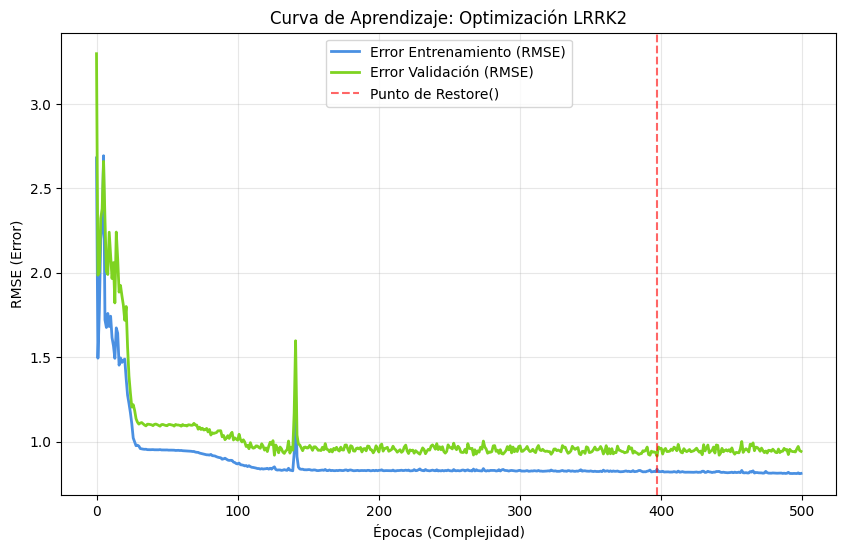

In [10]:
plt.figure(figsize=(10, 6))
x_axis = range(0, epochs, check_interval)

plt.plot(x_axis, train_errors, label='Error Entrenamiento (RMSE)', color='#4A90E2', lw=2)
plt.plot(x_axis, valid_errors, label='Error Validación (RMSE)', color='#7ED321', lw=2)

# Marcamos el punto donde el Callback probablemente hizo el mejor guardado
idx_min_val = np.argmin(valid_errors)
plt.axvline(x=x_axis[idx_min_val], color='red', linestyle='--', alpha=0.6, label='Punto de Restore()')

plt.title('Curva de Aprendizaje: Optimización LRRK2')
plt.xlabel('Épocas (Complejidad)')
plt.ylabel('RMSE (Error)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Resultados del modelo

In [23]:
import numpy as np

# 1. Definimos la métrica (Pearson R2 es estándar en química)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

# 2. Evaluamos el modelo
train_score = final_model.evaluate(train_dataset, [metric])
valid_score = final_model.evaluate(valid_dataset, [metric])
test_score = final_model.evaluate(test_dataset, [metric])

print(f"R^2 en Entrenamiento: {train_score['pearson_r2_score']:.3f}")
print(f"R^2 en Validación: {valid_score['pearson_r2_score']:.3f}")
print(f"R^2 en Test (Moléculas nuevas): {test_score['pearson_r2_score']:.3f}")

R^2 en Entrenamiento: 0.866
R^2 en Validación: 0.513
R^2 en Test (Moléculas nuevas): 0.556


TypeError: unsupported format string passed to dict.__format__

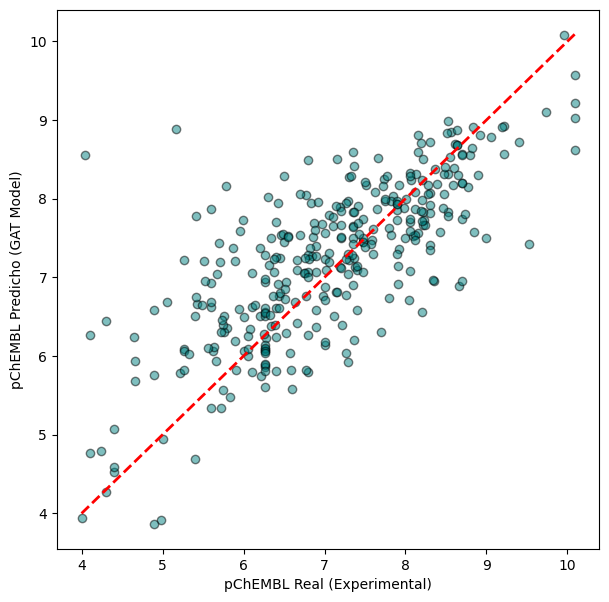

In [24]:
# Predecimos
test_pred = final_model.predict(test_dataset)
test_true = test_dataset.y

plt.figure(figsize=(7, 7))
plt.scatter(test_true, test_pred, alpha=0.5, c='teal', edgecolors='k')
plt.plot([test_true.min(), test_true.max()], [test_true.min(), test_true.max()], 'r--', lw=2)
plt.xlabel('pChEMBL Real (Experimental)')
plt.ylabel('pChEMBL Predicho (GAT Model)')
plt.title(f'Validación Externa (Test Set)\n$R^2$ Final: {test_score:.3f}')
plt.tight_layout()
plt.show()

### Guardar modelo final

In [25]:
# Crea una carpeta específica para la entrega final
ruta_final = "./MODELO_FINAL_TFG_ENTREGA"
final_model.save_checkpoint(max_checkpoints_to_keep=1, model_dir=ruta_final)

print(f"Modelo exportado correctamente en: {ruta_final}")

Modelo exportado correctamente en: ./MODELO_FINAL_TFG_ENTREGA


### Cargar modelo final

In [ ]:
import optuna
import deepchem as dc

# 1. Cargamos el estudio desde el archivo .db
storage_name = "sqlite:///optuna_lrrk2_estudio.db"
study = optuna.load_study(study_name="lrrk2_optimization", storage=storage_name)

# 2. Defines la arquitectura (DEBE ser igual a la de Optuna)
modelo_cargado = dc.models.GATModel(
    n_tasks=1,
    graph_attention_layers=[16] * study.best_params['n_layers'],
    n_attention_heads=study.best_params['n_heads'],
    # ... resto de parámetros ...
    model_dir="./MODELO_FINAL_TFG_ENTREGA" 
)

# 3. Restauras los pesos
modelo_cargado.restore()

# 4. ¡A predecir!
# pchembl_predicha = modelo_cargado.predict(nuevas_moleculas_dataset)

In [14]:
study.best_params

{'n_layers': 2,
 'n_heads': 8,
 'dropout': 0.37281627781373505,
 'lr': 0.0005245545365690975}

In [15]:
final_model.learning_rate

0.0005245545365690975